In [ ]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3+x**2 - 2**4 + x

In [ ]:
f(2.0)

-7.0

In [ ]:
xs = torch.arange(1, 15, .5)
xs

tensor([ 1.0000,  1.5000,  2.0000,  2.5000,  3.0000,  3.5000,  4.0000,  4.5000,
         5.0000,  5.5000,  6.0000,  6.5000,  7.0000,  7.5000,  8.0000,  8.5000,
         9.0000,  9.5000, 10.0000, 10.5000, 11.0000, 11.5000, 12.0000, 12.5000,
        13.0000, 13.5000, 14.0000, 14.5000])

In [ ]:
ys = f(xs)
ys

tensor([-11.0000,  -9.2500,  -7.0000,  -4.2500,  -1.0000,   2.7500,   7.0000,
         11.7500,  17.0000,  22.7500,  29.0000,  35.7500,  43.0000,  50.7500,
         59.0000,  67.7500,  77.0000,  86.7500,  97.0000, 107.7500, 119.0000,
        130.7500, 143.0000, 155.7500, 169.0000, 182.7500, 197.0000, 211.7500])

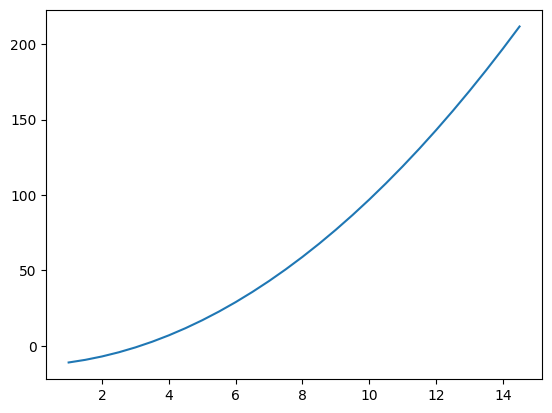

In [ ]:
plt.plot(xs, ys)


In [ ]:
h = 0.000000000001 # cant be too large since we are limited to a certain number of bits
x = 3.0
sl = (f(x + h) - f(x))/h


In [ ]:
A = 4.0
B = 13.0
C = 12/5
D = A*B + C
print(D)

54.4


In [ ]:
h = 0.00001

#inputs
A = 4.0
B = 13.0
C = 12/5

D1 = A*B + C
A += h
D2 = A*B + C

print('D1:', D1)
print('D2:', D2)
print('slope:', ((D2 - D1)/h))

D1: 54.4
D2: 54.40013
slope: 12.99999999986312


In [ ]:
class Value:
  def __init__(self,data, _children=(), _op='', label='') -> None:
    self.data = data
    self.grad = 0.0
    self._prev = set(_children) # this keeps track of the parents of the returned data
    self._op = _op # keeps track of the operations we are using, and so we know what operation we did to the two parents to get the outputed data value
    self.label = label


  def __repr__(self) -> str:  # this allows us to print out a nice looking value and not like bit notation values
    return f"Value(data={self.data})"

  #say we wanna add a and b, we gotta make a function for add since python doesn't know how to add two Value objects
  def __add__(self,other) -> 'Value':
    out = Value(self.data + other.data, (self, other), '+') # "+" here is addition like normal since we are using the actual data number not the Value object
    return out

  def __mul__(self,other) -> 'Value': # must say "mul" and not "multiply"
    out = Value(self.data * other.data, (self, other), '*')
    return out

  def tanh(self) -> 'Value':
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    return out

a = Value(2.0, label='A')
b = Value(-3.0, label='B')
c = Value(10.0, label ='C')
e = a + b
e.label = 'E'
d = e + c; d.label = 'D'
f = Value(-2.0, label='F')
L = d*f; L.label = 'L'
d, d._prev, d._op

(Value(data=9.0), {Value(data=-1.0), Value(data=10.0)}, '+')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


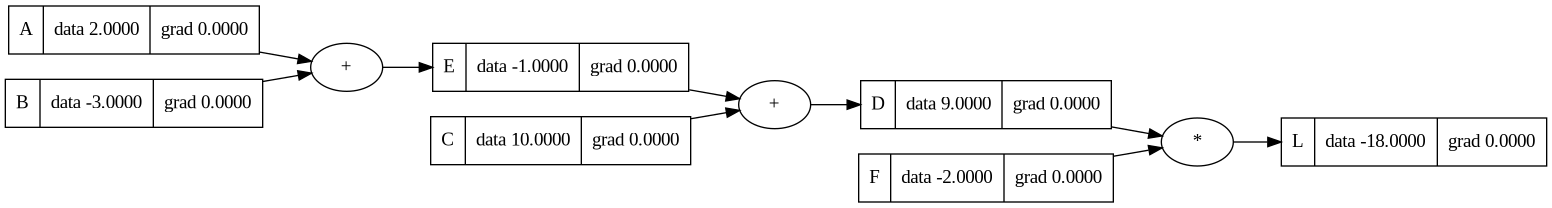

In [ ]:
!apt-get install -y graphviz

from graphviz import Digraph
from IPython.display import Image, display

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='png', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}", shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

diagram = draw_dot(L)
diagram.render('colab_output', cleanup=True)
display(Image('colab_output.png'))

In [ ]:
a.data += 0.01 * a.grad
a.data += 0.01 * b.grad
c.data += 0.01 * c.grad
# d.data += 0.01 * d.grad
f.data += 0.01 * f.grad

# e = a + b
# d = e + c
# L = d * f

print(L.data)

-18.0


In [ ]:
def lol():

  h = .00001

  a = Value(2.0, label='A')
  b = Value(-3.0, label='B')
  c = Value(10.0, label ='C')
  e = a + b
  e.label = 'E'
  d = e + c; d.label = 'D'
  f = Value(-2.0, label='F')
  L = d*f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='A')
  b = Value(-3.0, label='B')
  c = Value(10.0, label ='C')
  e = a + b
  e.label = 'E'
  d = e + c; d.label = 'D'
  # d.data += h
  f = Value(-2.0, label='F')
  L = d*f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

0.0


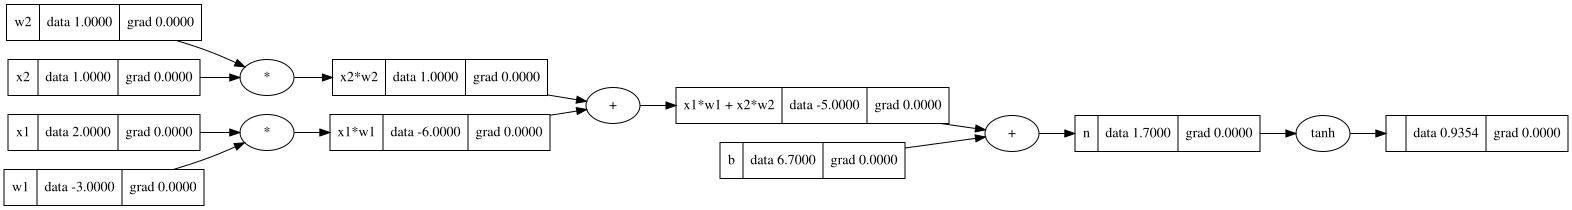

In [ ]:
#inputs x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(1.0, label='x2')

#weights w1 and w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.7, label='b')

#x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
draw_dot(o)